# 1. 读取RCTD的权重并接入对象

因为在RCTD进行了反卷积来预测各类细胞对于每个spot的贡献，因此将RCTD的权重得出后，接入空间对象， 然后通过各类细胞在Spot中的预测占比， 绘出边界图

In [1]:
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import squidpy as sq
import matplotlib.pyplot as plt

project_dir = Path("/Users/georicl/Documents/sc_sncell_github")
result_dir = project_dir / "data/processed/CID4535_rctd_v1"

adata = ad.read_h5ad(
    project_dir
    / "data/processed/CID4535_spatial/spatial_qc_filtering.h5ad"
)

weights = pd.read_csv(
    result_dir / "rctd_weights_spot_by_celltype.csv",
    index_col=0,
)


# 按空间对象的 spot 顺序排列预测结果
weights = weights.loc[adata.obs_names].copy()


print("空间对象：", adata.shape)
print("权重表：", weights.shape)

空间对象： (1102, 19237)
权重表： (1102, 13)


因为权重中是一个原始的值，合计不为1，在保留原始合计总权重的情况下，要展示细胞的相对权重

In [2]:
weight_sum = weights.sum(axis=1)
relative_weights = weights.div(weight_sum, axis=0)

# 将rctd的原始权重和每spot中的相对权重导入到anndata中
adata.obsm["rctd_weights"] = weights
adata.obsm["rctd_relative_weights"] = relative_weights
adata.obs["rctd_weight_sum"] = weight_sum


In [3]:
plot_types = {
    "CAFs": "rctd_CAF",
    "T cells CD8+": "rctd_CD8",
    "Cancer Epithelial": "rctd_cancer",
    "PVL": "rctd_PVL",
}


后续展示作者提供病例标签组作为对照组

/Users/georicl/Documents/sc_sncell_github/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  color_source_vector = adata.obs_vector(value_to_plot, layer=layer)


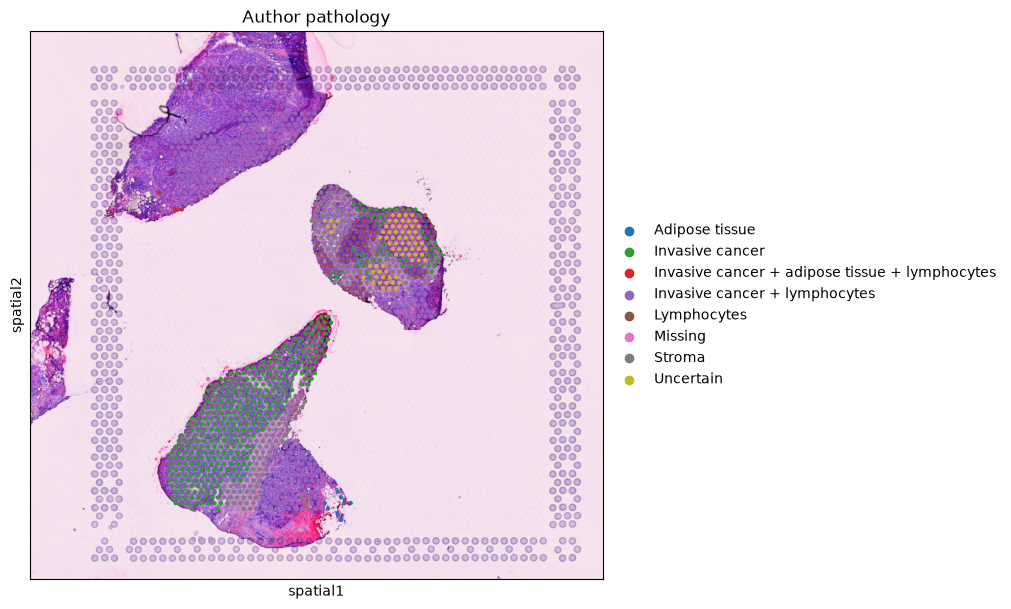

In [4]:
adata.obs["pathology_display"] = (
    adata.obs["Classification"]
    .astype("string")
    .fillna("Missing")
    .astype("category")
)

sq.pl.spatial_scatter(
    adata,
    library_id="CID4535",
    img_res_key="hires",
    color="pathology_display",
    figsize=(10, 10),
    title="Author pathology",
)

现在绘制主要观测的四类细胞的分布情况

/Users/georicl/Documents/sc_sncell_github/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  color_source_vector = adata.obs_vector(value_to_plot, layer=layer)


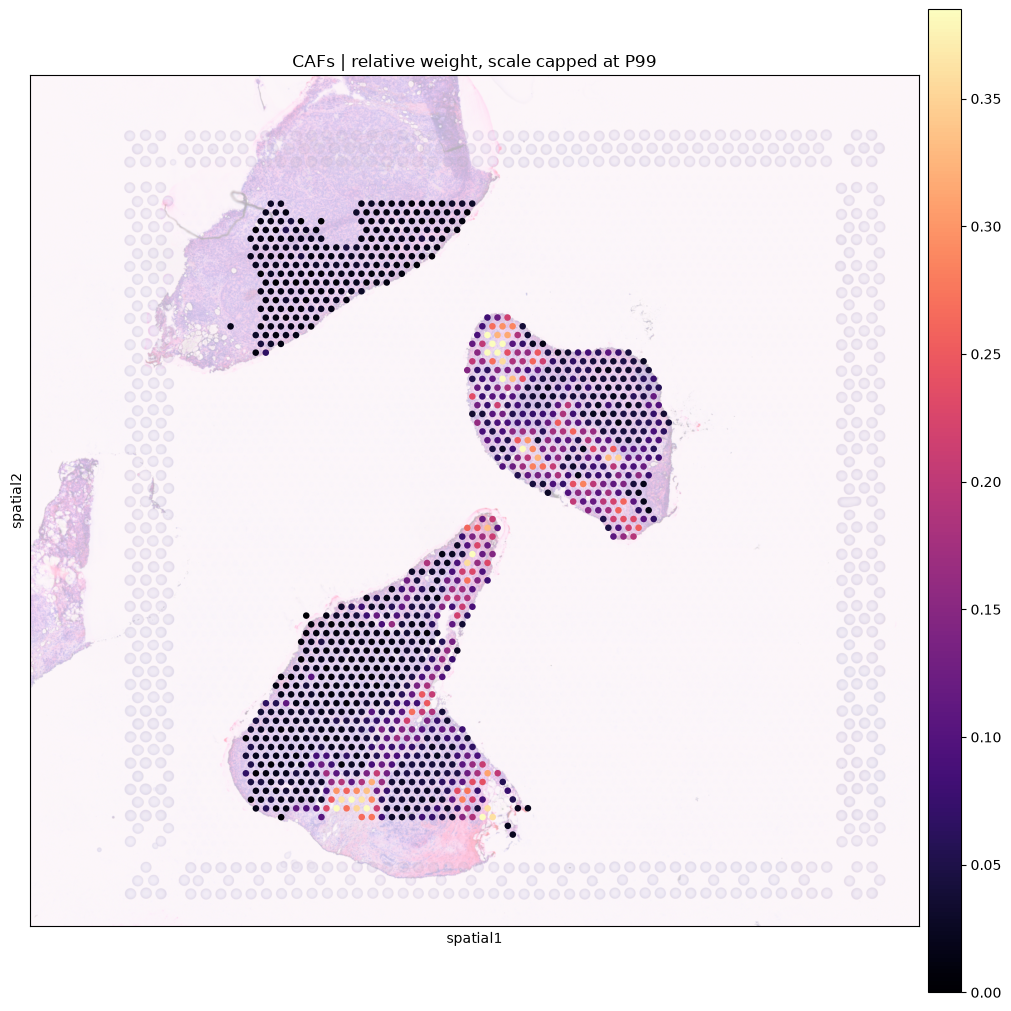

/Users/georicl/Documents/sc_sncell_github/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  color_source_vector = adata.obs_vector(value_to_plot, layer=layer)


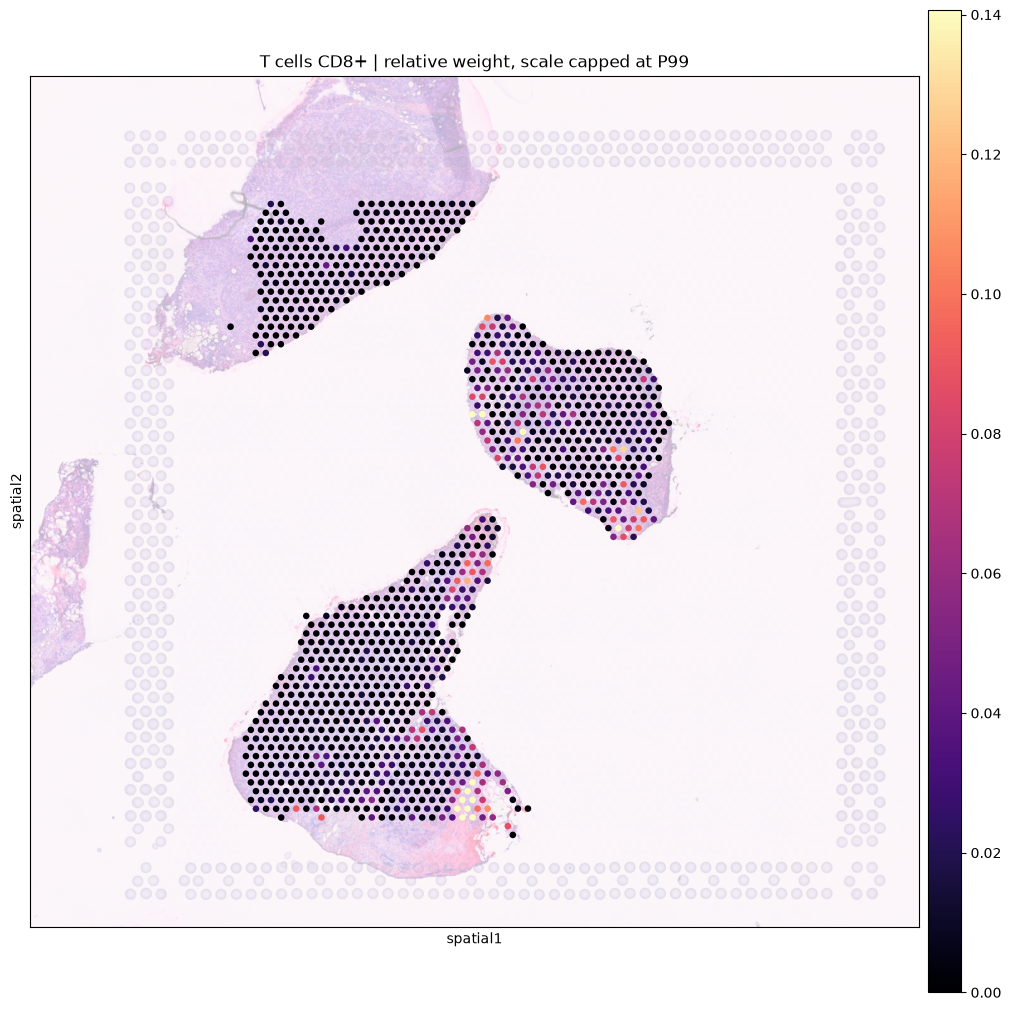

/Users/georicl/Documents/sc_sncell_github/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  color_source_vector = adata.obs_vector(value_to_plot, layer=layer)


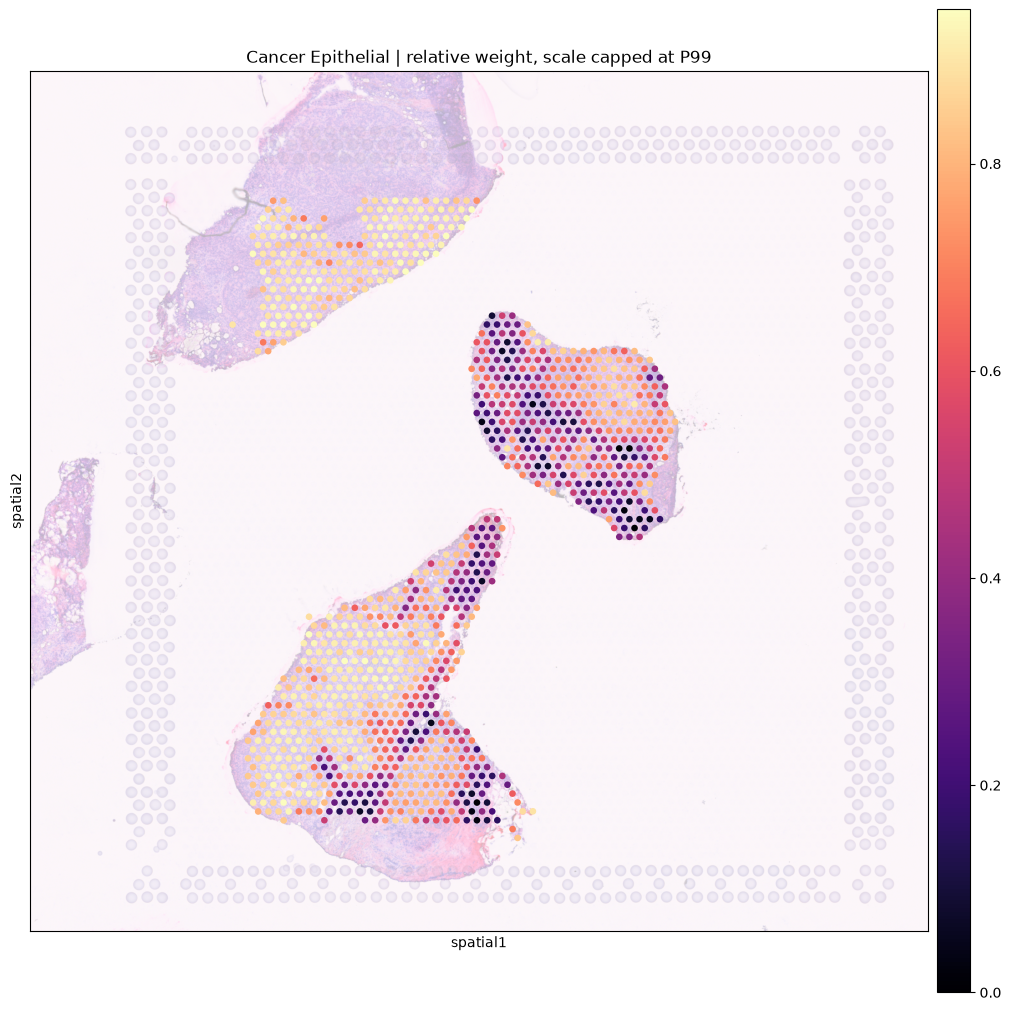

/Users/georicl/Documents/sc_sncell_github/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  color_source_vector = adata.obs_vector(value_to_plot, layer=layer)


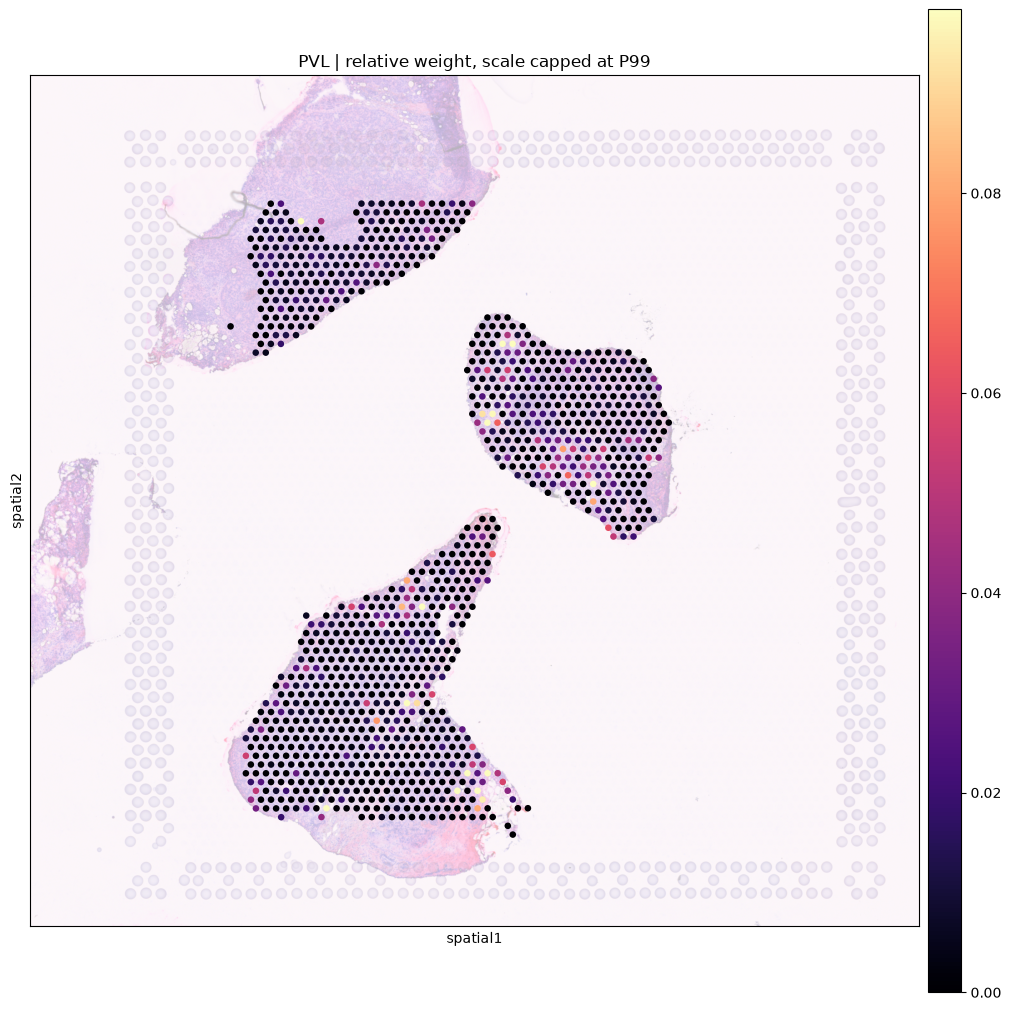

In [5]:
for cell_type, column in plot_types.items():
    # 按 spot 条码将相对权重写入绘图使用的 obs 列
    adata.obs[column] = relative_weights.loc[adata.obs_names, cell_type]

    # 每类分别设置颜色上限，减少极少数高值对色阶的影响
    color_max = float(adata.obs[column].quantile(0.99))

    # 防止第 99 百分位为 0
    if color_max <= 0:
        color_max = float(adata.obs[column].max())
    if color_max <= 0:
        color_max = 1.0

    sq.pl.spatial_scatter(
        adata,
        library_id="CID4535",
        img_res_key="hires",
        color=column,
        cmap="magma",
        vmin=0,
        vmax=color_max,
        img_alpha=0.3,
        alpha=1.0,
        figsize=(10, 10),
        title=f"{cell_type} | relative weight, scale capped at P99",
    )

    plt.show()